In [12]:
import numpy as np
import matplotlib.pyplot as plt
from src.util import load_csv

In [13]:
xa, ya = load_csv(r"C:\cs229-journey\cs229-journey\problem_sets\PS2\data\ds1_a.csv", add_intercept = True)
xb, yb = load_csv(r"C:\cs229-journey\cs229-journey\problem_sets\PS2\data\ds1_b.csv", add_intercept = True)

We have a look at both data sets

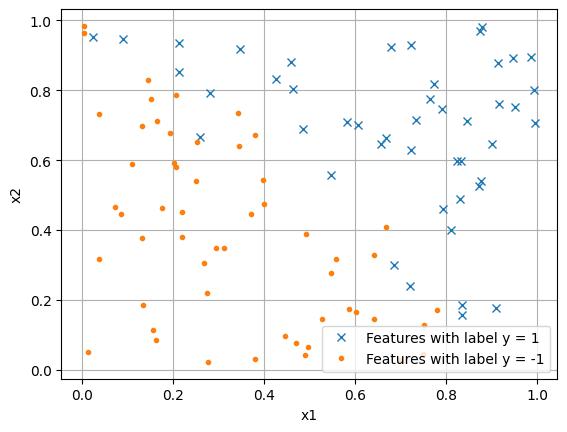

In [14]:
plt.plot(xa[:, 1][ya == 1], xa[:, 2][ya == 1], 'x')
plt.plot(xa[:, 1][ya == -1], xa[:, 2][ya == -1], '.', label = "")
plt.legend(["Features with label y = 1", "Features with label y = -1"])
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
plt.show()

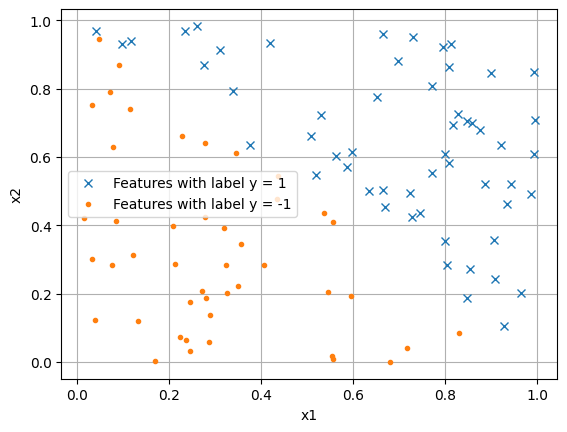

In [15]:
plt.plot(xb[:, 1][yb == 1], xb[:, 2][yb == 1], 'x')
plt.plot(xb[:, 1][yb == -1], xb[:, 2][yb == -1], '.', label = "")
plt.legend(["Features with label y = 1", "Features with label y = -1"])
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
plt.show()

Ati first glance, the main diference between both datasets is that the dataset B seems linearly separable while the dataset A is not.

In [16]:
def calc_grad(X, Y, theta):
    """Compute the gradient of the loss with respect to theta."""
    m, n = X.shape

    margins = Y * X.dot(theta)
    probs = 1.0 / (1 + np.exp(margins))
    grad = -(1.0 / m) * (X.T.dot(probs * Y))

    return grad


def logistic_regression(X, Y):
    """Train a logistic regression model."""
    m, n = X.shape
    theta = np.zeros(n)
    learning_rate = 10

    i = 0
    while True and i < 2e5:
        i += 1
        prev_theta = theta
        grad = calc_grad(X, Y, theta)
        theta = theta - learning_rate * grad
        if i % 10000 == 0:
            print("Finished %d iterations" % i)
        if np.linalg.norm(prev_theta - theta) < 1e-15:
            print("Converged in %d iterations" % i)
            break
    return theta




In [17]:
#Train on a and b
logistic_regression(xa, ya)
logistic_regression(xb, yb)

Finished 10000 iterations
Finished 20000 iterations
Finished 30000 iterations
Converged in 30386 iterations
Finished 10000 iterations
Finished 20000 iterations
Finished 30000 iterations
Finished 40000 iterations
Finished 50000 iterations
Finished 60000 iterations
Finished 70000 iterations
Finished 80000 iterations
Finished 90000 iterations
Finished 100000 iterations
Finished 110000 iterations
Finished 120000 iterations
Finished 130000 iterations
Finished 140000 iterations
Finished 150000 iterations
Finished 160000 iterations
Finished 170000 iterations
Finished 180000 iterations
Finished 190000 iterations
Finished 200000 iterations


array([-153.67257509,  154.19451821,  153.65990501])

We see that the algorithm converges within 30300 iterations for the dataset A but it does not for the dataset B.

This is because the logistic regression cannot converge for a perfectly separable dataset. The idea behind this is the following.

The sigmoid function has the following limits
$$
    \lim_{\theta\to\infty} \sigma_\theta(x) = 0, \;\; \text{if x < 0}
$$
$$
    \lim_{\theta\to\infty} \sigma_\theta(x) = 1, \;\; \text{if x > 0}
$$

Lets suppose that our data is centered (therefore the intercept is zero) and the vertical line $x=0$ can seperate our two classes.
The function to optimize is the LE:
$$
    l(\theta) = \sum_i y_i\log{\sigma_\theta(x_i)} + (1 - y_i)\log{(1-\sigma_\theta(x_i))}
$$
This summation has two terms. The terms in which $y_i = 0$, look like $\log{(1-\sigma_\theta(x_i))}$, and beacuse of the perfect separation we know that for this terms $x_i < 0$. By the first limit we calculated, this means that 
$$
    \lim_{\theta\to\infty} \sigma_\theta(x) = 0
$$
for every $x_i$ associated with a $y_i = 0$. Them, after appliying the log, we get that the limit is 
$$
    \lim_{\theta\to\infty} \log{(1-\sigma_\theta(x_i))} = 0
$$
The same ideas can be use for the terms with $y_i = 1$, obtaining:
$$
    \lim_{\theta\to\infty} \log{(\sigma_\theta(x_i))} = 0
$$
So no matter what $\theta $ is, you can always drive the objetive function upwards by increasing $\theta$ towards infinity.

In the case on non perfectly separable points we would have points $y_i = 1$ associated with $x_i < 0$, and therefore the limit
$$
    \lim_{\theta\to\infty} \log{(\sigma_\theta(x_i))} = - \infty
$$
We would have also points $y_i = 0$ associated with $x_i < 0$, and therefore the limit
$$
    \lim_{\theta\to\infty} \log{(1-\sigma_\theta(x_i))} = 0
$$
And in between (because the log likelihood is continuous) there is a maximum of the function.